In [122]:
import numpy as np
import pandas as pd

In [123]:
df=pd.read_csv("/content/loan_data.csv")

In [124]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [126]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [127]:
df["person_gender"].value_counts()

,count
person_gender,
male,24841
female,20159


In [128]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [129]:
print(df["person_gender"].dtype)

object


In [130]:
categories_column=df.select_dtypes(include=object).columns

In [131]:
for values in categories_column:
  print(pd.DataFrame(df[values].value_counts()))



               count
person_gender       
male           24841
female         20159
                  count
person_education       
Bachelor          13399
Associate         12028
High School       11972
Master             6980
Doctorate           621
                       count
person_home_ownership       
RENT                   23443
MORTGAGE               18489
OWN                     2951
OTHER                    117
                   count
loan_intent             
EDUCATION           9153
MEDICAL             8548
VENTURE             7819
PERSONAL            7552
DEBTCONSOLIDATION   7145
HOMEIMPROVEMENT     4783
                                count
previous_loan_defaults_on_file       
Yes                             22858
No                              22142


In [132]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder


In [133]:
Nominal_columns=["person_gender", "loan_intent","previous_loan_defaults_on_file"]
ordinal_columns=["person_education","person_home_ownership",]

le=LabelEncoder()
for column in Nominal_columns:
  df[column]=le.fit_transform(df[column])


In [134]:
oe=OrdinalEncoder(categories=[
    ["High School", "Associate", "Bachelor", "Master", "Doctorate"],
    ["OTHER", "RENT", "MORTGAGE", "OWN"]
])


In [135]:
df[ordinal_columns]=(oe.fit_transform(df[ordinal_columns])).astype(int)

In [136]:
print(df["person_education"].unique())

[3 0 2 1 4]


In [137]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,3,71948.0,0,1,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,0,12282.0,0,3,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,0,12438.0,3,2,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,2,79753.0,0,1,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,3,66135.0,1,1,35000.0,3,14.27,0.53,4.0,586,0,1


In [138]:
corelation_matrix=df.corr()

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Co-relation')

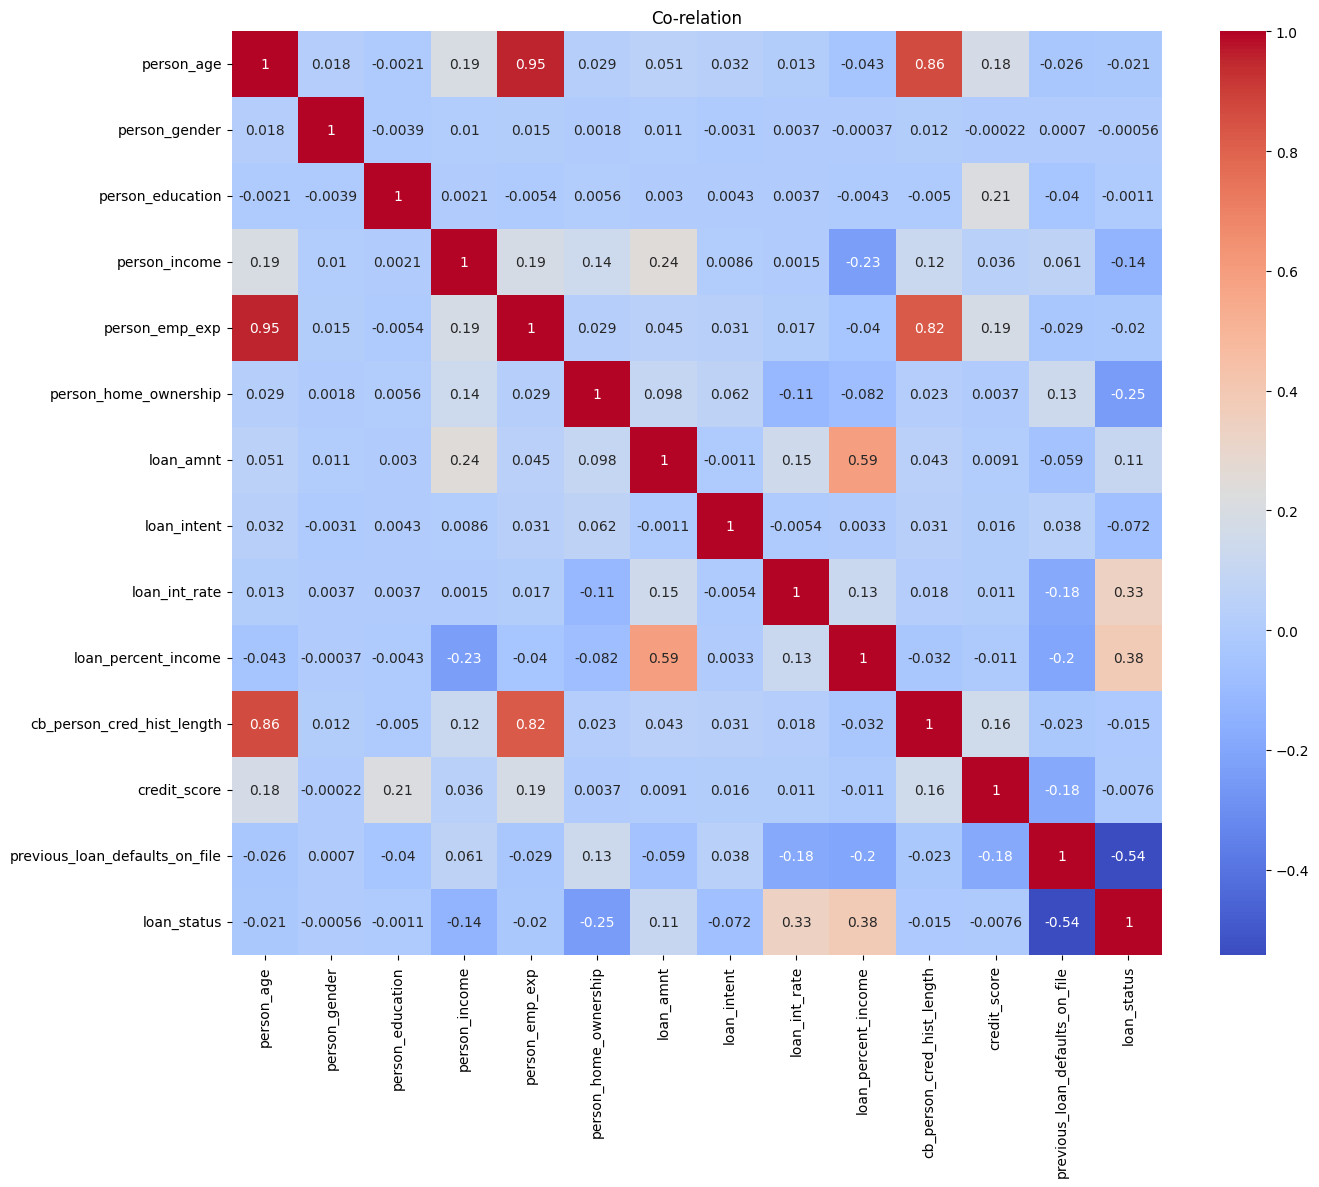

In [140]:
plt.figure(figsize=(15,12))
sns.heatmap(corelation_matrix,annot=True,cmap='coolwarm')
plt.title("Co-relation")

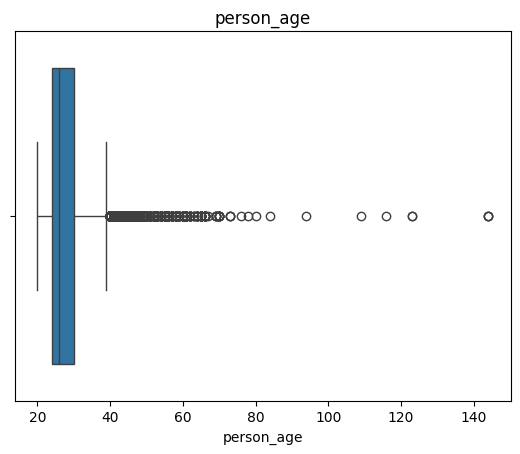

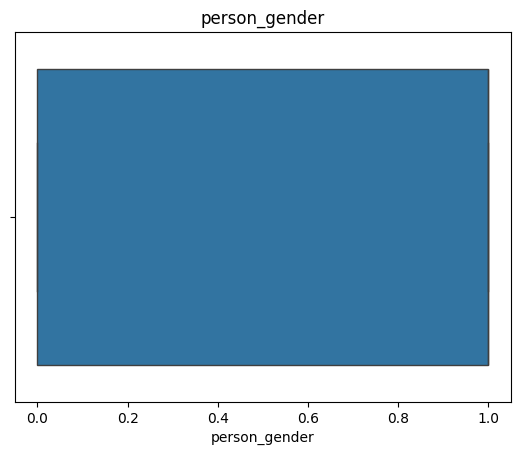

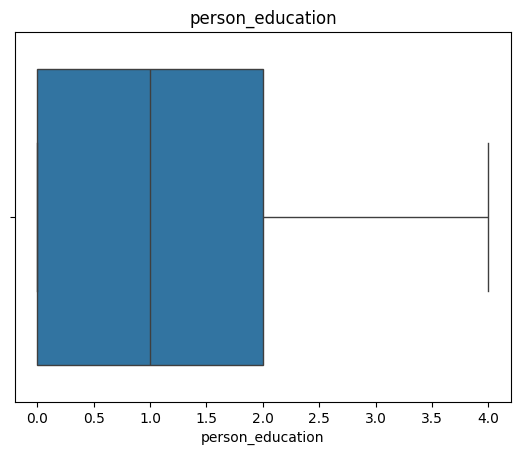

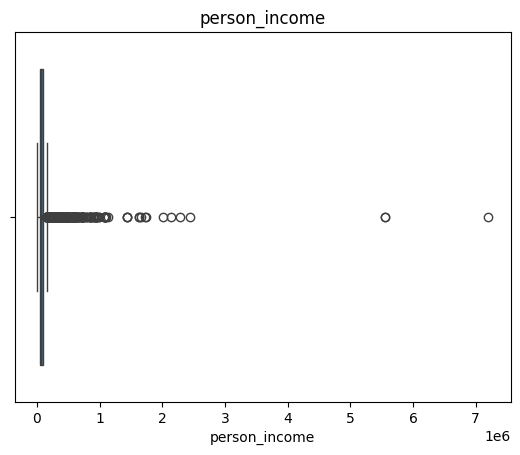

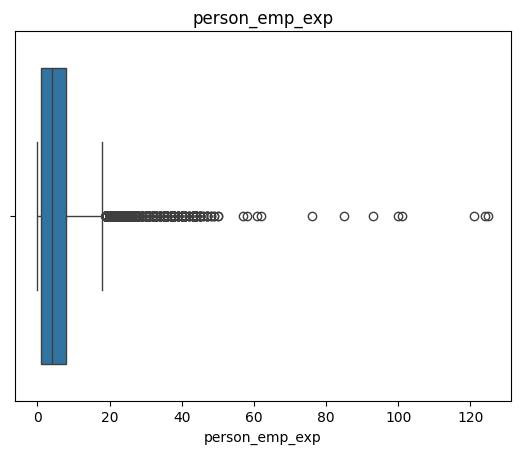

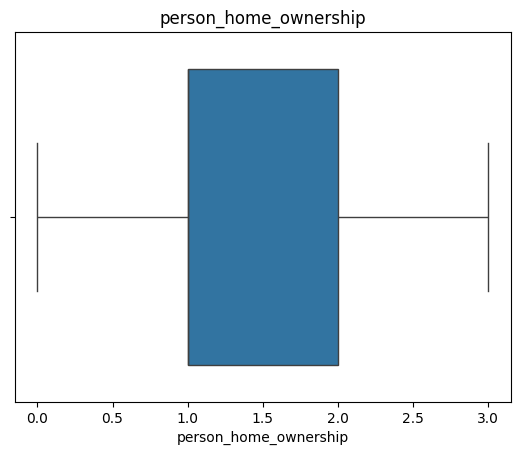

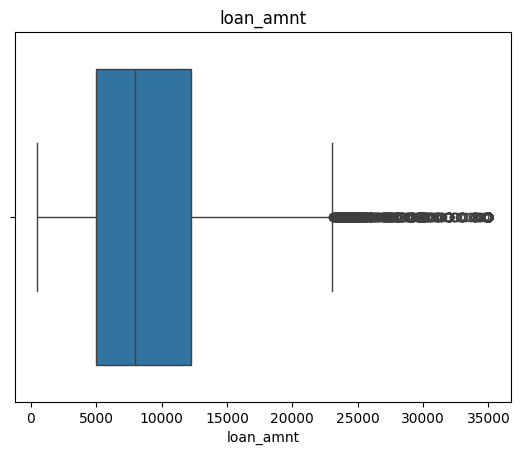

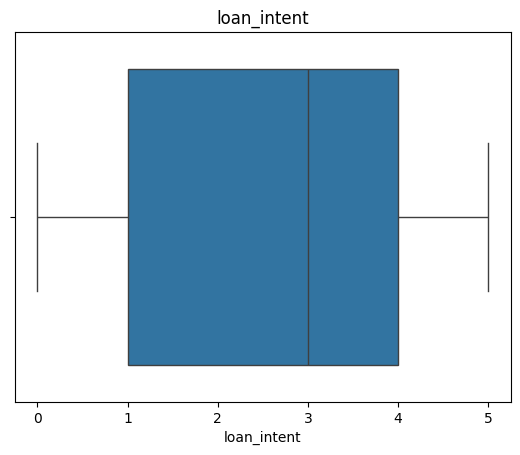

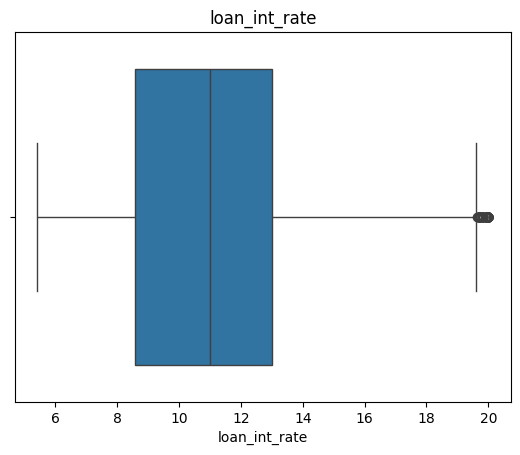

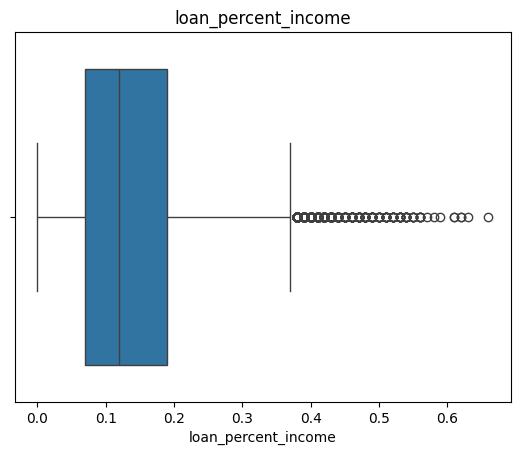

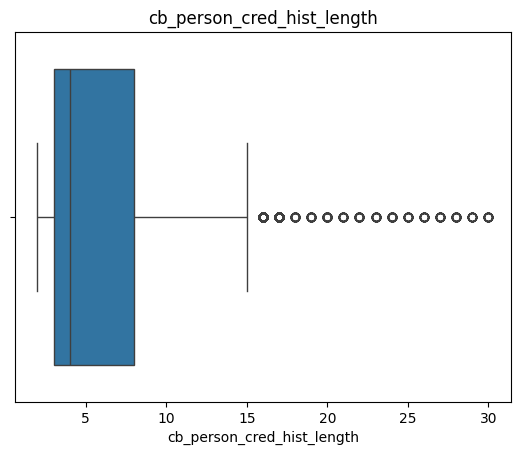

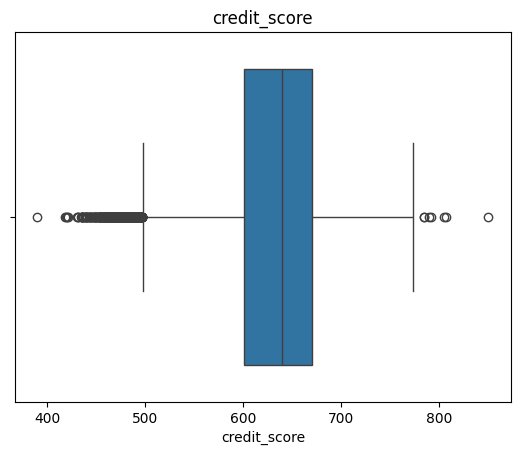

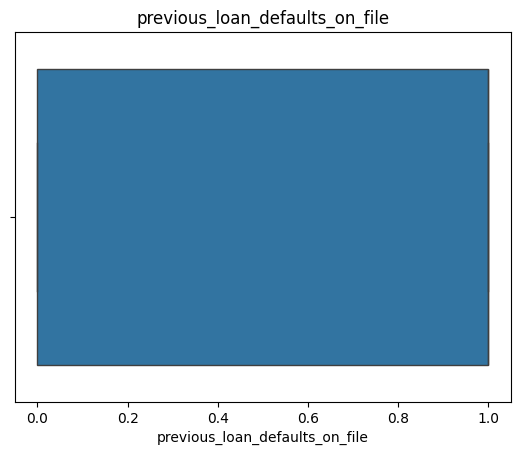

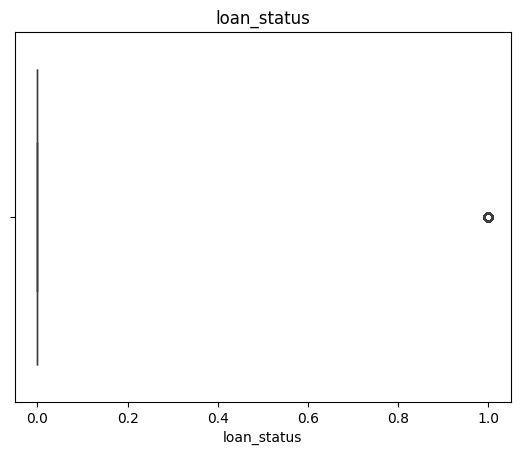

In [141]:
for column in df.columns:
  sns.boxplot(x=df[column])
  plt.title(column)
  plt.show()


In [142]:
for column in df.columns:
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)

  IQR=Q3-Q1

  lower_bound=Q1 - 1.5* IQR
  upper_bound=Q3 + 1.5* IQR

  outliers= df[(df[column]<lower_bound)|(df[column]>upper_bound)]
  print(f"{column}: {len(outliers)}")
  print(outliers)

person_age: 2188
       person_age  person_gender  person_education  person_income  \
81          144.0              1                 2       300616.0   
183         144.0              1                 1       241424.0   
575         123.0              0                 0        97140.0   
747         123.0              1                 2        94723.0   
29120        40.0              0                 2      1440915.0   
...           ...            ...               ...            ...   
44916        42.0              0                 0       100310.0   
44923        47.0              1                 1        46637.0   
44947        42.0              1                 4       705960.0   
44972        43.0              1                 1       184295.0   
44977        43.0              1                 1        22639.0   

       person_emp_exp  person_home_ownership  loan_amnt  loan_intent  \
81                125                      1     4800.0            5   
183       

In [143]:
print(
    (df["person_emp_exp"] > df["person_age"]).sum()
)

0


In [144]:
df.shape

(45000, 14)

In [145]:
df = df[df["person_age"] <= 100]

In [146]:
df.shape

(44993, 14)

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44993 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_gender                   44993 non-null  int64  
 2   person_education                44993 non-null  int64  
 3   person_income                   44993 non-null  float64
 4   person_emp_exp                  44993 non-null  int64  
 5   person_home_ownership           44993 non-null  int64  
 6   loan_amnt                       44993 non-null  float64
 7   loan_intent                     44993 non-null  int64  
 8   loan_int_rate                   44993 non-null  float64
 9   loan_percent_income             44993 non-null  float64
 10  cb_person_cred_hist_length      44993 non-null  float64
 11  credit_score                    44993 non-null  int64  
 12  previous_loan_defaults_on_file  44993

In [158]:
x=df.drop("loan_status",axis=1)
print(x)
y = df.iloc[:, -1]
print(y)

       person_age  person_gender  person_education  person_income  \
0            22.0              0                 3        71948.0   
1            21.0              0                 0        12282.0   
2            25.0              0                 0        12438.0   
3            23.0              0                 2        79753.0   
4            24.0              1                 3        66135.0   
...           ...            ...               ...            ...   
44995        27.0              1                 1        47971.0   
44996        37.0              0                 1        65800.0   
44997        33.0              1                 1        56942.0   
44998        29.0              1                 2        33164.0   
44999        24.0              1                 0        51609.0   

       person_emp_exp  person_home_ownership  loan_amnt  loan_intent  \
0                   0                      1    35000.0            4   
1                   0      

In [161]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8)

In [163]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((35994, 13), (8999, 13), (35994,), (8999,))

In [164]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.fit_transform(x_test)

In [170]:
model=LogisticRegression()

In [171]:
x_train_scaled.shape,x_test_scaled.shape,y_train.shape,y_test.shape

((35994, 13), (8999, 13), (35994,), (8999,))

In [172]:
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [173]:
y_pred=model.predict(x_test_scaled)

In [174]:
y_pred

array([1, 0, 1, ..., 1, 0, 0])

In [175]:
pd.DataFrame(
    {
        'Actual': y_test,
        'predicted': y_pred
    }
)

,Actual,predicted
16029,1,1
34100,0,0
27943,1,1
15667,0,0
27790,0,0
...,...,...
28913,0,0
6820,0,0
198,1,1
21190,0,0


In [177]:
from sklearn.metrics import accuracy_score
acc_score=accuracy_score(y_test,y_pred)
acc_score

0.8954328258695411

In [179]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[6552,  447],
       [ 494, 1506]])

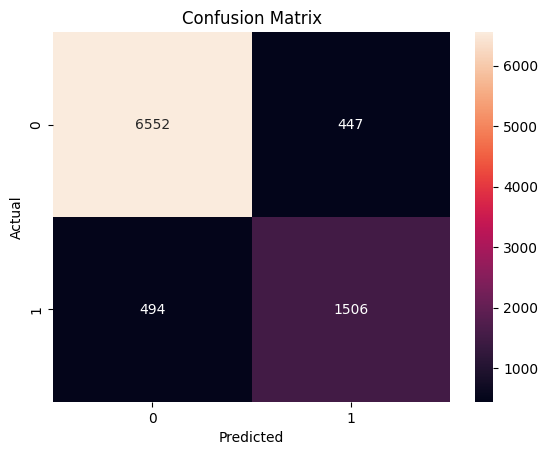

In [185]:
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [187]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6999
           1       0.77      0.75      0.76      2000

    accuracy                           0.90      8999
   macro avg       0.85      0.84      0.85      8999
weighted avg       0.89      0.90      0.89      8999



In [188]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", auc)

ROC AUC: 0.9541868838405486


In [190]:
for feature, coef in zip(x.columns, model.coef_[0]):
    print(feature, coef)

person_age 0.2907988270166132
person_gender -0.002056925981088685
person_education 0.009627799551498643
person_income 0.12164738294972607
person_emp_exp -0.20276425293351555
person_home_ownership -0.5271987536743689
loan_amnt -0.6569678118635112
loan_intent -0.24456677896608572
loan_int_rate 0.9908487647863236
loan_percent_income 1.3470382882993641
cb_person_cred_hist_length -0.06937940884971165
credit_score -0.46876724977872364
previous_loan_defaults_on_file -4.545974418728886
